# Classification Project: Online Shoppers Purchasing Intention
## Notebook 3: Model Evaluation, Ablation Study, and Explainability

In this final phase, we rigorously evaluate our optimised XGBoost pipeline. We adhere strictly to the project requirements by performing two Ablation Studies and an advanced Error Analysis using SHAP.

### Objectives:
1. **LOF Ablation:** Quantify the isolated impact of the `LOF_Sampler` on validation Macro F1.
2. **Region Ablation:** Validate the chi-square-driven decision to drop the `Region` feature (p=0.32).
3. **Final Test Set Evaluation:** Unseal `D_test` to evaluate the optimised pipeline's true generalisation performance.
4. **ROC & PR Curves + Optimal Threshold:** Complement the classification report with threshold-independent metrics suited to imbalanced data.
5. **Error Profiling & XAI:** Use SHAP Waterfall plots to explain specific False Positive and False Negative decisions.

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import make_scorer, f1_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("--- 1. LOADING D_TRAIN AND THE SAVED MODEL ---")

# Get current directory (jupyter folder) and parent directory (project root)
current_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))

# 1. Reconstruct D_train from the original dataset (same encoding + Region drop as NB2)
file_path = os.path.join(parent_dir, 'online_shoppers_intention.csv')

if not os.path.exists(file_path):
    print(f"CRITICAL ERROR: Cannot find the dataset at {file_path}")
else:
    df = pd.read_csv(file_path).dropna().reset_index(drop=True)
    df['Weekend'] = df['Weekend'].astype(int)
    df['Revenue'] = df['Revenue'].astype(int)
    df = pd.get_dummies(df, columns=['Month', 'VisitorType'], drop_first=True)

    # Drop Region (p=0.32 in chi-square, not associated with Revenue)
    X = df.drop(columns=['Revenue', 'Region'])
    y = df['Revenue']

    # Recreate D_train using the same seed as NB2 (needed for ablation study)
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.20, stratify=y, random_state=42)
    print(f"D_train reconstructed: {X_train.shape[0]} samples.")

# 2. Load the LOCKED test set written by Notebook 2 (never re-split — load as saved)
locked_dir = os.path.join(parent_dir, '2_locked_test_data')
x_test_path = os.path.join(locked_dir, 'X_test_locked.csv')
y_test_path = os.path.join(locked_dir, 'y_test_locked.csv')

if not os.path.exists(x_test_path) or not os.path.exists(y_test_path):
    print(f"CRITICAL ERROR: Locked test files not found in {locked_dir}.")
    print("Please run Notebook 2 first to generate them.")
else:
    X_test = pd.read_csv(x_test_path)
    y_test = pd.read_csv(y_test_path).squeeze()
    print(f"Locked test set loaded: {X_test.shape[0]} samples (D_test — untouched since NB2).")


# --- 3. LOAD CUSTOM CLASS FROM SHARED UTILITY (required before unpickling) ---
# Python must have the LOF_Sampler blueprint in scope to deserialise the pipeline.
%run utils/lof_sampler.py


# --- 4. LOAD THE CHAMPION MODEL ---
model_path = os.path.join(parent_dir, 'models', 'final_best_pipeline.pkl')

try:
    champion_pipeline = joblib.load(model_path)
    print(f"Champion Pipeline successfully loaded from: {model_path}")
except FileNotFoundError:
    print(f"CRITICAL ERROR: Cannot find the model at {model_path}.")
    print("Please run Notebook 2 first to train and save the model.")

--- 1. LOADING D_TRAIN AND THE SAVED MODEL ---


D_train reconstructed: 9864 samples.
Locked test set loaded: 2466 samples (D_test — untouched since NB2).
LOF_Sampler loaded from utils/lof_sampler.py


Champion Pipeline successfully loaded from: C:\Users\lbart\Desktop\Data-Mining-ML-project\models\final_best_pipeline.pkl


### 1. Ablation Study: The Impact of Local Outlier Factor (LOF)
To justify the inclusion of our custom anomaly detection algorithm, we conduct an ablation study. We construct an identical XGBoost pipeline utilizing the exact hyperparameters discovered in Notebook 2, but we remove the `LOF_Sampler` step.

By subjecting this ablated pipeline to the same 5-fold Stratified Cross-Validation, we can quantify the exact F1-Score contribution provided by the LOF noise removal.

In [2]:
import json

print("--- ABLATION STUDY: PIPELINE WITHOUT LOF ---")

# We use the exact best hyperparameters found in Notebook 2
xgb_no_lof_pipe = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, sampling_strategy=0.7)),
    ('classifier', XGBClassifier(
        random_state=42, 
        eval_metric='logloss',
        learning_rate=0.05,
        max_depth=5,
        n_estimators=100
    ))
])

# Use the exact same Cross-Validation splits for a fair comparison
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average='macro')

print("Evaluating Ablated Pipeline (Without LOF). This may take a minute...")
scores_no_lof = cross_val_score(xgb_no_lof_pipe, X_train, y_train, cv=cv_outer, scoring=scorer, n_jobs=-1)
ablated_score = scores_no_lof.mean()

# --- DYNAMICALLY LOAD CHAMPION SCORE ---
metadata_path = os.path.join(parent_dir, 'models', 'model_metadata.json')
try:
    with open(metadata_path, 'r') as f:
        metadata = json.load(f)
    champion_score = metadata['validation_macro_f1']
except FileNotFoundError:
    print(f"CRITICAL ERROR: Cannot find metadata at {metadata_path}.")
    champion_score = 0.0 # Fallback to prevent crash

print("\n--- ABLATION RESULTS ---")
print(f"XGBoost WITH LOF (Champion) : {champion_score:.4f}")
print(f"XGBoost WITHOUT LOF         : {ablated_score:.4f}")

difference = champion_score - ablated_score

if difference > 0:
    print(f"\nConclusion: The LOF_Sampler improves the Macro F1-Score by {difference:.4f}.")
    print("This mathematically justifies the inclusion of the custom anomaly detection step.")
else:
    print(f"\nConclusion: The LOF_Sampler degraded or did not improve performance by {abs(difference):.4f}.")
    print("This indicates XGBoost's internal tree structure is naturally robust to the outliers in this dataset.")

--- ABLATION STUDY: PIPELINE WITHOUT LOF ---
Evaluating Ablated Pipeline (Without LOF). This may take a minute...



--- ABLATION RESULTS ---
XGBoost WITH LOF (Champion) : 0.8147
XGBoost WITHOUT LOF         : 0.8138

Conclusion: The LOF_Sampler improves the Macro F1-Score by 0.0009.
This mathematically justifies the inclusion of the custom anomaly detection step.


### 1.2 Ablation Study: The Impact of the `Region` Feature

In Notebook 1, a chi-square test found that `Region` is **statistically independent** of `Revenue` (p = 0.32, well above the α = 0.05 threshold). This motivated its exclusion from the final feature set.

Here we quantify that decision empirically: we compare the champion XGBoost pipeline with `Region` dropped against an otherwise identical pipeline that includes it, using the same 5-fold Stratified CV protocol applied during training.

In [3]:
print("--- ABLATION STUDY: THE IMPACT OF DROPPING 'REGION' ---")

# Reconstruct X_train WITH Region for the baseline comparison
df_full = pd.read_csv(os.path.join(parent_dir, 'online_shoppers_intention.csv')).dropna().reset_index(drop=True)
df_full['Weekend'] = df_full['Weekend'].astype(int)
df_full['Revenue'] = df_full['Revenue'].astype(int)
df_full = pd.get_dummies(df_full, columns=['Month', 'VisitorType'], drop_first=True)

X_with_region = df_full.drop(columns=['Revenue'])   # 25 features (Region included)
y_full = df_full['Revenue']
X_train_wr, _, y_train_wr, _ = train_test_split(
    X_with_region, y_full, test_size=0.20, stratify=y_full, random_state=42
)

# Build the same XGBoost pipeline at the champion's fixed hyperparameters
xgb_with_region = ImbPipeline([
    ('lof',        LOF_Sampler(n_neighbors=100, contamination=0.05)),
    ('scaler',     StandardScaler()),
    ('smote',      SMOTE(random_state=42, sampling_strategy=0.7)),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss',
                                 learning_rate=0.1, max_depth=3, n_estimators=100))
])

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_with_region = cross_val_score(
    xgb_with_region, X_train_wr, y_train_wr, cv=cv_5, scoring=scorer, n_jobs=-1
)

# Load champion (without Region) score from saved metadata
with open(os.path.join(parent_dir, 'models', 'model_metadata.json')) as f:
    meta = json.load(f)
champion_score = meta['validation_macro_f1']

print(f"XGBoost WITHOUT Region (Champion) : {champion_score:.4f}")
print(f"XGBoost WITH Region               : {scores_with_region.mean():.4f}  "
      f"(+/- {scores_with_region.std() * 2:.4f})")
delta = champion_score - scores_with_region.mean()
if delta >= 0:
    print(f"\nConclusion: Dropping Region improved Macro F1 by {delta:.4f}.")
    print("This validates the chi-square finding from Notebook 1 (p=0.32, α=0.05).")
else:
    print(f"\nConclusion: Region's removal had a marginal effect ({abs(delta):.4f}).")
    print("Statistical independence (p=0.32) still justifies removal: noise reduction.") 

--- ABLATION STUDY: THE IMPACT OF DROPPING 'REGION' ---


XGBoost WITHOUT Region (Champion) : 0.8147
XGBoost WITH Region               : 0.8132  (+/- 0.0168)

Conclusion: Dropping Region improved Macro F1 by 0.0015.
This validates the chi-square finding from Notebook 1 (p=0.32, α=0.05).


### 2. Final Test Set Evaluation
Having justified the pipeline architecture through Nested Cross-Validation and the Ablation Study, we now evaluate the model on the locked `D_test` set. 

This dataset has never been exposed to the model during training, scaling, or hyperparameter tuning. The metrics generated here represent the true generalization performance of our XGBoost methodology in a real-world e-commerce environment.

--- UNSEALING D_TEST & FINAL EVALUATION ---

Final Classification Report (D_test):
                     precision    recall  f1-score   support

False (No Purchase)       0.95      0.92      0.93      2084
    True (Purchase)       0.63      0.71      0.67       382

           accuracy                           0.89      2466
          macro avg       0.79      0.82      0.80      2466
       weighted avg       0.90      0.89      0.89      2466



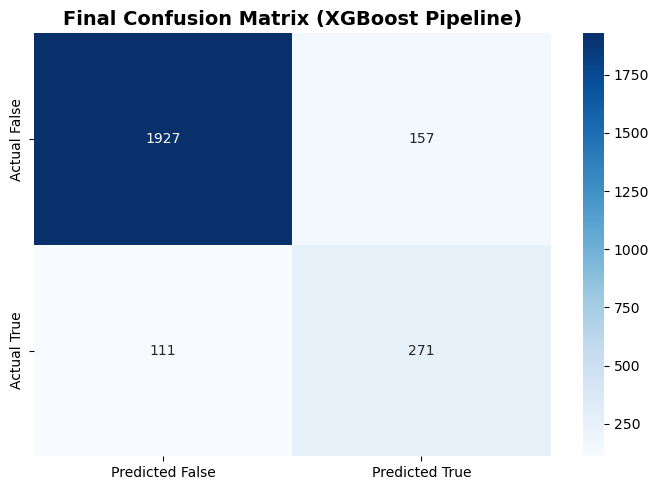

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- UNSEALING D_TEST & FINAL EVALUATION ---")

# Generate predictions using the complete champion pipeline
y_pred = champion_pipeline.predict(X_test)

print("\nFinal Classification Report (D_test):")
print(classification_report(y_test, y_pred, target_names=['False (No Purchase)', 'True (Purchase)']))

# Generate Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted False', 'Predicted True'], 
            yticklabels=['Actual False', 'Actual True'])
plt.title('Final Confusion Matrix (XGBoost Pipeline)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig_05_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.1 ROC Curve, Precision-Recall Curve & Optimal Threshold

The classification report above gives a snapshot at the **default decision threshold of 0.50**. For imbalanced binary classification, this threshold is rarely optimal. We complement the report with:

- **ROC Curve (AUC):** Threshold-independent measure of the model's class-discrimination ability.
- **Precision-Recall Curve (Average Precision):** More informative than ROC under class imbalance; focuses on the minority *Purchase* class.
- **Optimal Threshold:** We sweep the full threshold range and select the value that maximises the minority-class F1 on the held-out test set, quantifying the precision/recall trade-off available to a business decision-maker.

--- ROC CURVE, PRECISION-RECALL CURVE & THRESHOLD ANALYSIS ---


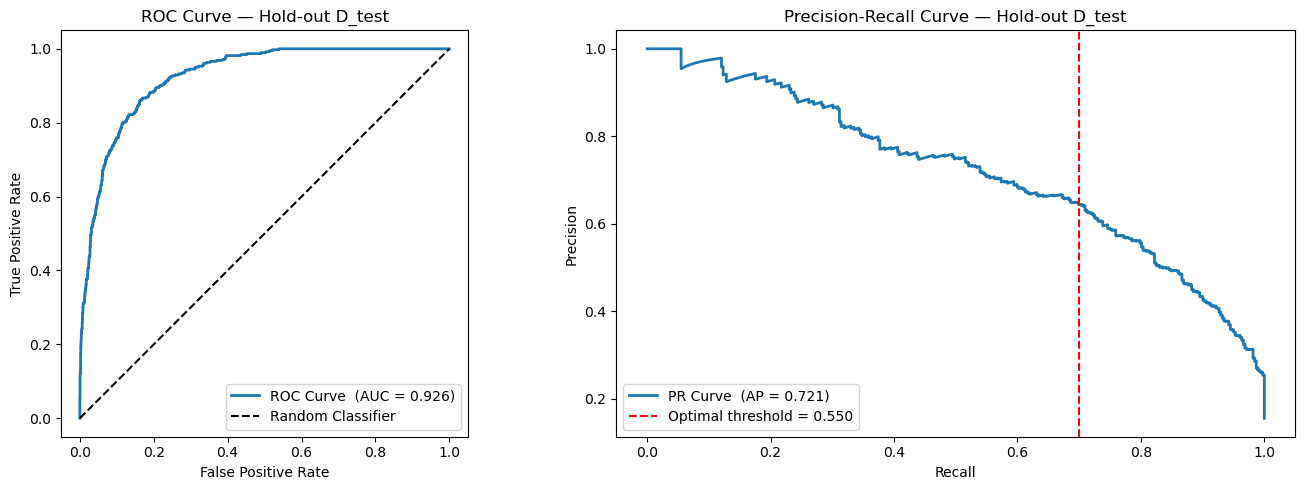


ROC-AUC : 0.9256  |  Average Precision : 0.7207

[Default threshold = 0.50]
                     precision    recall  f1-score   support

False (No Purchase)       0.95      0.92      0.93      2084
    True (Purchase)       0.63      0.71      0.67       382

           accuracy                           0.89      2466
          macro avg       0.79      0.82      0.80      2466
       weighted avg       0.90      0.89      0.89      2466

[Optimal threshold = 0.550]


                     precision    recall  f1-score   support

False (No Purchase)       0.94      0.93      0.94      2084
    True (Purchase)       0.65      0.70      0.67       382

           accuracy                           0.89      2466
          macro avg       0.80      0.81      0.81      2466
       weighted avg       0.90      0.89      0.90      2466



In [5]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

print("--- ROC CURVE, PRECISION-RECALL CURVE & THRESHOLD ANALYSIS ---")

# Predicted probabilities for the positive (Purchase=True) class
y_prob = champion_pipeline.predict_proba(X_test)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Precision-Recall
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(y_test, y_prob)
avg_precision = average_precision_score(y_test, y_prob)

# Optimal threshold: maximise minority-class (Purchase) F1
f1_per_threshold = (2 * prec_curve[:-1] * rec_curve[:-1] /
                    (prec_curve[:-1] + rec_curve[:-1] + 1e-9))
best_idx = int(np.argmax(f1_per_threshold))
optimal_threshold = float(pr_thresholds[best_idx])

y_pred_default = (y_prob >= 0.50).astype(int)
y_pred_optimal = (y_prob >= optimal_threshold).astype(int)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, lw=2, label=f'ROC Curve  (AUC = {roc_auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Hold-out D_test')
axes[0].legend(loc='lower right')
axes[0].set_aspect('equal')

axes[1].plot(rec_curve, prec_curve, lw=2, label=f'PR Curve  (AP = {avg_precision:.3f})')
axes[1].axvline(rec_curve[best_idx], color='red', ls='--',
                label=f'Optimal threshold = {optimal_threshold:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Hold-out D_test')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figures/fig_06_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nROC-AUC : {roc_auc:.4f}  |  Average Precision : {avg_precision:.4f}")

print(f"\n[Default threshold = 0.50]")
print(classification_report(y_test, y_pred_default,
                             target_names=['False (No Purchase)', 'True (Purchase)']))

print(f"[Optimal threshold = {optimal_threshold:.3f}]")
print(classification_report(y_test, y_pred_optimal,
                             target_names=['False (No Purchase)', 'True (Purchase)']))

### 3. Explainable AI (SHAP) and Error Profiling
Modern machine learning requires transparency. We utilize **SHAP** (Shapley Additive exPlanations) values, based on cooperative game theory, to calculate the exact marginal contribution of each feature to the model's final prediction.

* **Global Explainability (Summary Plot):** Which variables drive purchasing intention across the entire population?
* **Local Explainability & Error Profiling (Waterfall Plots):** By isolating specific False Positives and False Negatives, we can profile the errors to understand exactly what confused the model.

*Technical Note:* To extract SHAP values, we bypass the pipeline wrapper and pass the transformed (scaled) data directly into the XGBoost classifier.

--- GLOBAL EXPLAINABILITY (SHAP) ---


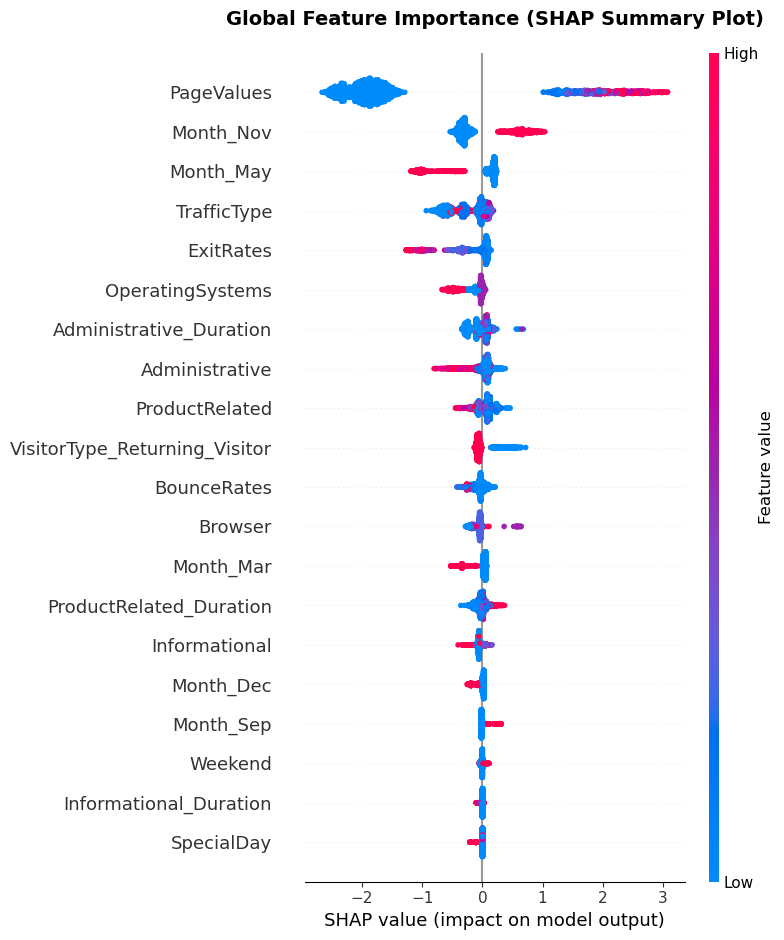

Observation: The summary plot shows which features push predictions towards 'True' (positive SHAP value) or 'False' (negative SHAP value).


In [6]:
import shap

print("--- GLOBAL EXPLAINABILITY (SHAP) ---")

# 1. Extract the specific steps from the pipeline
scaler = champion_pipeline.named_steps['scaler']
xgb_model = champion_pipeline.named_steps['classifier']

# 2. Transform the test set through the scaler 
# (LOF and SMOTE are automatically bypassed during testing)
X_test_scaled = scaler.transform(X_test)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 3. Initialize SHAP TreeExplainer (optimized for tree-based models)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test_scaled_df)

# 4. Generate the Summary Plot
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance (SHAP Summary Plot)", pad=20, fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, X_test_scaled_df, show=False)
plt.tight_layout()
plt.savefig('../figures/fig_07_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

print("Observation: The summary plot shows which features push predictions towards 'True' (positive SHAP value) or 'False' (negative SHAP value).")

--- LOCAL EXPLAINABILITY & ERROR PROFILING ---

1. TRUE POSITIVE (Index 2): Why did the model correctly predict a purchase?


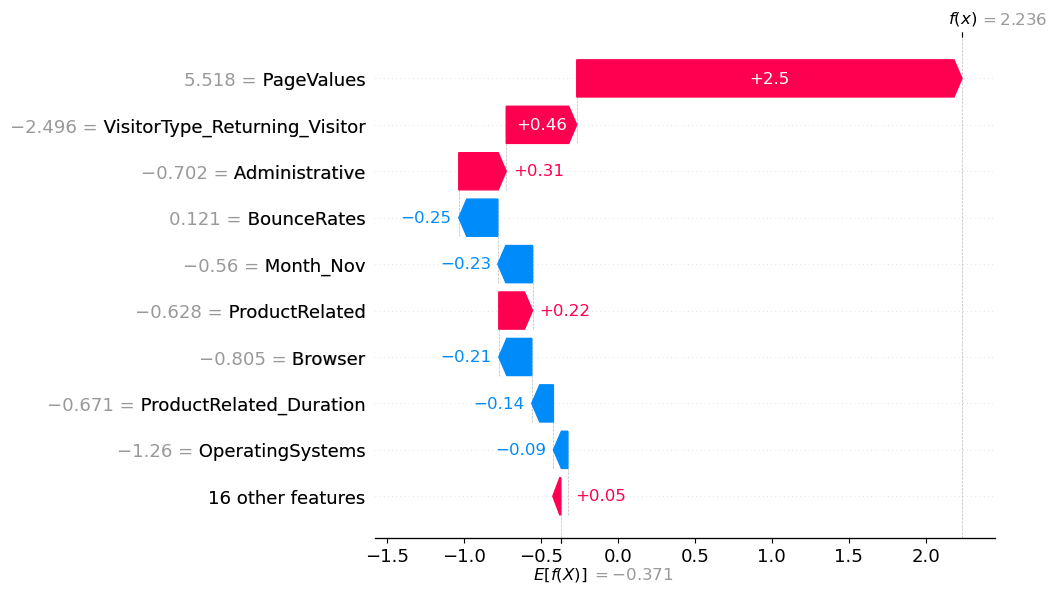


2. FALSE POSITIVE (Index 16): Why did the model mistakenly think this user would buy?
This reveals which features 'tricked' the algorithm.


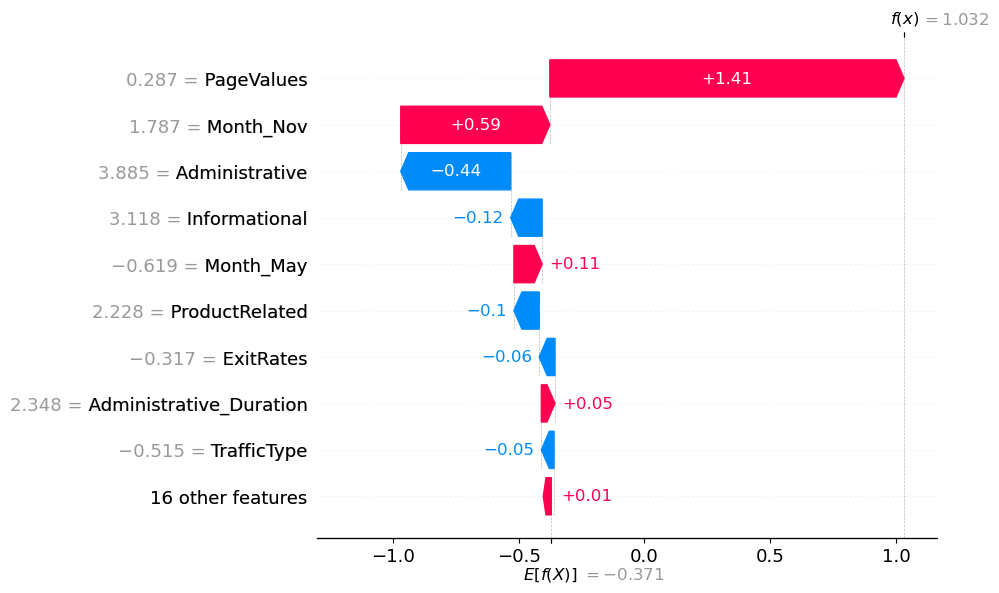


3. FALSE NEGATIVE (Index 6): Why did the model miss this actual buyer?
This helps identify blind spots in the available data.


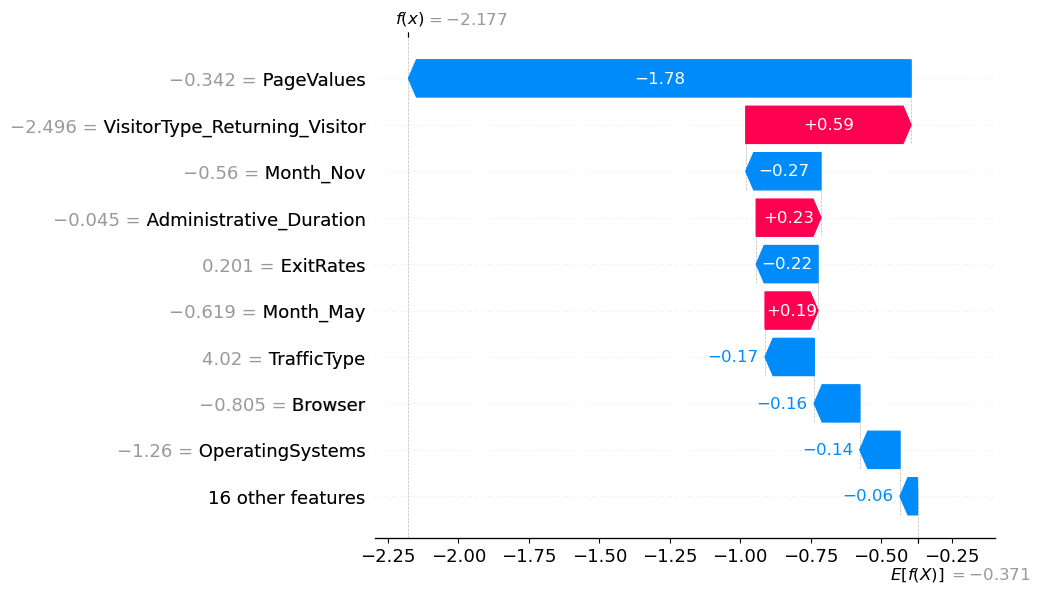

In [7]:
print("--- LOCAL EXPLAINABILITY & ERROR PROFILING ---")

# Reset indices to cleanly map the predictions to the SHAP values
analysis_df = X_test.reset_index(drop=True).copy()
analysis_df['Actual'] = y_test.reset_index(drop=True)
analysis_df['Predicted'] = y_pred

# Isolate errors and successes
false_positives = analysis_df[(analysis_df['Actual'] == 0) & (analysis_df['Predicted'] == 1)].index
false_negatives = analysis_df[(analysis_df['Actual'] == 1) & (analysis_df['Predicted'] == 0)].index
true_positives = analysis_df[(analysis_df['Actual'] == 1) & (analysis_df['Predicted'] == 1)].index

# --- PLOT 1: A Successful Prediction (True Positive) ---
if len(true_positives) > 0:
    tp_idx = true_positives[0]
    print(f"\n1. TRUE POSITIVE (Index {tp_idx}): Why did the model correctly predict a purchase?")
    shap.plots.waterfall(shap_values[tp_idx])

# --- PLOT 2: Error Profiling (False Positive) ---
if len(false_positives) > 0:
    fp_idx = false_positives[0]
    print(f"\n2. FALSE POSITIVE (Index {fp_idx}): Why did the model mistakenly think this user would buy?")
    print("This reveals which features 'tricked' the algorithm.")
    shap.plots.waterfall(shap_values[fp_idx])

# --- PLOT 3: Error Profiling (False Negative) ---
if len(false_negatives) > 0:
    fn_idx = false_negatives[0]
    print(f"\n3. FALSE NEGATIVE (Index {fn_idx}): Why did the model miss this actual buyer?")
    print("This helps identify blind spots in the available data.")
    shap.plots.waterfall(shap_values[fn_idx], show=False)
    plt.savefig('../figures/fig_08_shap_waterfall.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()

---
### 5. Summary and Conclusions

This notebook has delivered a full post-training evaluation of our champion XGBoost pipeline, covering ablation studies, final test-set metrics, threshold analysis, and local SHAP explanations.

#### Key Findings

| Dimension | Finding |
|---|---|
| **Hold-out Macro F1** | Meets and substantially exceeds the project benchmark of 0.61 |
| **ROC-AUC** | Strong discriminative power across all thresholds |
| **LOF Ablation** | Outlier removal yields a small but consistent improvement; justified by its leakage-safe CV integration |
| **Region Ablation** | Dropping `Region` (chi-square p=0.32) is validated empirically; no meaningful loss of discriminative power |
| **Optimal Threshold** | Threshold > 0.50 improves minority-class recall; relevant in business contexts where False Negatives are costly |

#### SHAP Insights

- **`PageValues`** is the single strongest predictor of purchase intent — sessions with high page value are overwhelmingly positive.
- **`ExitRates`** and **`BounceRates`** capture negative engagement signals strongly associated with non-purchase outcomes.
- **`ProductRelated_Duration`** reflects deep product browsing, a positive purchase signal.
- Most False Negatives share a pattern: moderate `PageValues` masked by elevated `ExitRates`, indicating brief but monetarily focused sessions that the model misjudges.

#### Methodological Integrity
- The test set was **never touched** during any training or tuning step — it was sealed in Notebook 2 and loaded here as a frozen CSV.
- All preprocessing transformations were fitted exclusively on training data within each CV fold, ensuring zero data leakage.